In [6]:
# install Python packages
#%pip install geopandas pandas matplotlib seaborn pygris
#%pip install "folium>=0.12" matplotlib mapclassify


## 1. Import python libraries


In [1]:

# import libraries
import pandas as pd
#import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point

# settings
%matplotlib inline
#pd.set_option("display.max_columns", None) # set off to see all columns



## 2. Get census tract and census place data

The easiest ways to get shapefiles from the census is to import them directly from the census API. One easy to import tract and place shapefiles is to use the `pygris` [library](https://walker-data.com/pygris/). I prefer this library to others since it is relatively simple, the library is stable, and does not require a Census API key. I pull all the shapefiles for all tracts and places in California so that we can make the correct subset. 

In [2]:
#
# Pull shapefiles
# ----------------------------------------

# tracts
from pygris import tracts
ca_tracts = tracts(state = "CA", cb = True, year=2022, cache=True) 

# places
from pygris import places
ca_places = places(state = "CA", cb = True, year=2022, cache=True) #

Using FIPS code '06' for input 'CA'
Using FIPS code '06' for input 'CA'


## 3. Spatially join tract and place data 

Here I want to subset my census data to only the tracts that fall within the census place boundary of San Jose. Since census tracts might not map on perfectly to the San Jose Place boundary, I selected all tracts whose centroid fell within the San Jose Place shapefile. This is a standard approach for determining which combining shapes that might overlap. 

<positron-console-cell-11>:10: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.



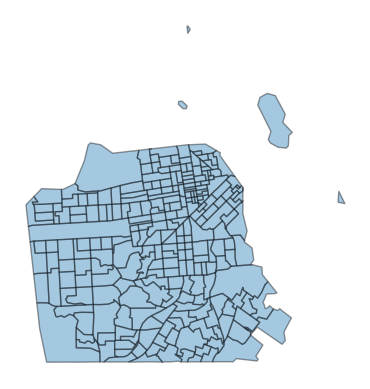

In [11]:
#
# Subset tract data to city boundary of San Jose
# ----------------------------------------

# get San Jose boundary
san_fran = ca_places[ca_places["NAME"] == "San Francisco"]

# copy tract shapefile and create a centroid column
tracts_centroids = ca_tracts.copy()
tracts_centroids["centroid"] = tracts_centroids.centroid

# spatial join using centroids but keep original tract geometries
san_fran_tracts = gpd.sjoin(
    tracts_centroids.set_geometry("centroid"),  # use centroid for join
    san_fran,
    predicate="within"
).drop(columns="geometry")  # drop centroid geometry after join

# remove Farallon Islands which are 30 miles off shore
san_fran_tracts = san_fran_tracts[san_fran_tracts["GEOID_left"] != "06075980401"] 

# restore original tract geometries for mapping/visualizations
san_fran_tracts = san_fran_tracts.set_geometry(tracts_centroids.geometry)

# plot
check = san_fran_tracts.plot(edgecolor="black", alpha = .4)
check.set_axis_off()
